# **Artificial Nerural Network from Scratch**

## 0.ライブラリのインポートとデータの生成

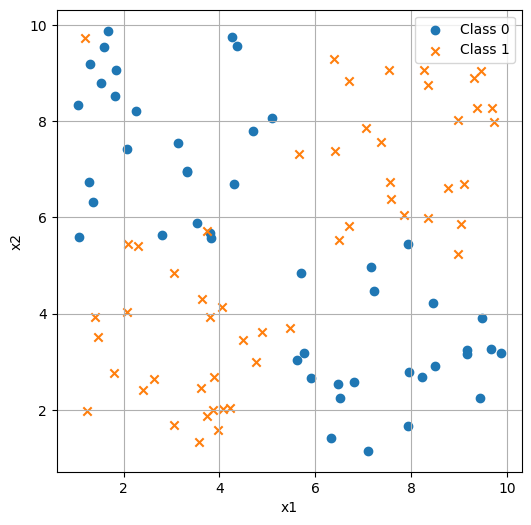

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
data_number = 100
input_data = np.random.uniform(1, 10, (data_number, 2))
labels = np.zeros(data_number)

for i in range(data_number):
    x1 = input_data[i, 0]
    x2 = input_data[i, 1]
    if (x1 > 5.5 and x2 > 5.5) or (x1 < 5.5 and x2 < 5.5):
        labels[i] = 1
    else:
        labels[i] = 0

for i in range(data_number):
    if np.random.rand() < 0.02:
        labels[i] = 1 - labels[i]

plt.figure(figsize=(6, 6))
plt.scatter(input_data[labels==0, 0], input_data[labels==0, 1], label="Class 0", marker="o")
plt.scatter(input_data[labels==1, 0], input_data[labels==1, 1], label="Class 1", marker="x")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

## 1.アルゴリズム

・前提条件  
要因1と要因2による結果の予測を、ロジスティック回帰分析のアルゴリズムを使い、活性化関数をシグモイド関数としたニューラルネットワークによる予測を行う。

### 1.1.誤差関数

要因1と要因2とバイアス1(b1)を各ノード(O11、O12)のインプット(Z11、Z12)とする。  
各ノードのアウトプットとバイアス2(b2)を最終ノード(O21)のインプット(Z21)とする。  
Z11 = b11 + w111x1 + w112x2  
Z12 = b12 + w121x1 + w122x2  
O11 = sigmoid(Z11)  
O12 = sigmoid(Z12)  
Z21 = b2 + w211O11 + w212O12  
O21 = sigmoid(Z21)  
E(誤差関数) = (Y - O21)^2



### 1.2.誤差逆伝播法(バックプロパゲーション)

要因1→O11かかる重みw111の変化が与えるEへのインパクト  
dE / dw111 = (dE / dO21)(dO21 / dZ21)(dZ21 / dO11)(dO11 / dZ11)(dZ11 / dw111)  

### 1.3.勾配降下法

勾配の更新の式(w111の場合)

w111 = w111 - alpha(2(O21 - Y)sigmoid(Z21)(1 - sigmoid(Z21))w211sigmoid(Z11)(1 - sigmoid(Z11))x1)

In [27]:
def S(z):
  return 1 / (1 + np.exp(-z))

init_weight = np.random.rand(3, 3)
w111 = init_weight[0, 0]
w112 = init_weight[0, 1]
w121 = init_weight[0, 2]
w122 = init_weight[1, 0]
b11 = init_weight[1, 1]
b12 = init_weight[1, 2]
w211 = init_weight[2, 0]
w212 = init_weight[2, 1]
b2 = init_weight[2, 2]

epochs = 1000
alpha = 0.01
loss_history = []

for j in range(epochs):
  total_loss = 0

  for i in range(data_number):
    x1 = input_data[i, 0]
    x2 = input_data[i, 1]
    label = labels[i]

    Z11 = b11 + w111*x1 + w112*x2
    Z12 = b12 + w121*x1 + w122*x2
    O11 = S(Z11)
    O12 = S(Z12)
    Z21 = b2 + w211*O11 + w212*O12
    O21 = S(Z21)

    dw111 = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*w211*S(Z11)*(1 - S(Z11))*x1
    dw112 = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*w211*S(Z11)*(1 - S(Z11))*x2
    db11  = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*w211*S(Z11)*(1 - S(Z11))
    db12  = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*w212*S(Z12)*(1 - S(Z12))
    dw121 = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*w212*S(Z12)*(1 - S(Z12))*x1
    dw122 = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*w212*S(Z12)*(1 - S(Z12))*x2
    dw211 = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*O11
    dw212 = 2*(O21 - label)*S(Z21)*(1 - S(Z21))*O12
    db2   = 2*(O21 - label)*S(Z21)*(1 - S(Z21))

    w111 -= alpha * dw111
    w112 -= alpha * dw112
    b11   -= alpha * db11
    b12   -= alpha * db12
    w121 -= alpha * dw121
    w122 -= alpha * dw122
    w211 -= alpha * dw211
    w212 -= alpha * dw212
    b2   -= alpha * db2

    total_loss += (O21 - label)**2

  loss_history.append(total_loss / data_number)

## 2.モデルの可視化

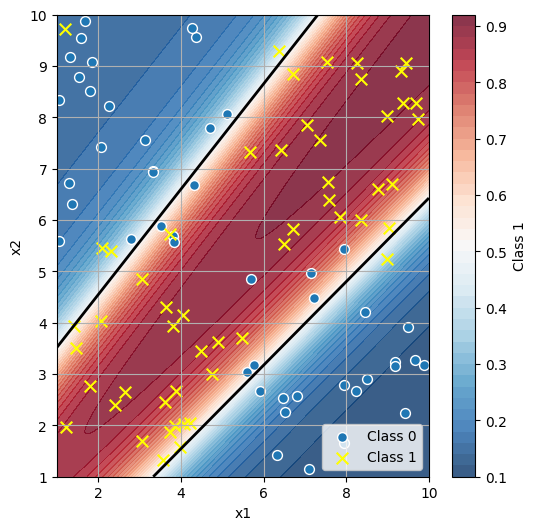

In [28]:
x1_range = np.linspace(1, 10, 200)
x2_range = np.linspace(1, 10, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)

Z11_grid = b11 + w111*X1 + w112*X2
Z12_grid = b12 + w121*X1 + w122*X2
O11_grid = S(Z11_grid); O12_grid = S(Z12_grid)
Z21_grid = b2 + w211*O11_grid + w212*O12_grid
O21_grid = S(Z21_grid)

plt.figure(figsize=(6, 6))
cp = plt.contourf(X1, X2, O21_grid, levels=50, cmap="RdBu_r", alpha=0.8)
plt.colorbar(cp, label="Class 1")
plt.contour(X1, X2, O21_grid, levels=[0.5], colors="black", linewidths=2)
plt.scatter(input_data[labels==0, 0], input_data[labels==0, 1], label="Class 0", marker="o", edgecolors="white", s=50)
plt.scatter(input_data[labels==1, 0], input_data[labels==1, 1], label="Class 1", marker="x", color="yellow", s=70)
plt.xlabel("x1");
plt.ylabel("x2")
plt.legend();
plt.grid(True)
plt.show()

## 3.検証

### 3.1.学習の進捗

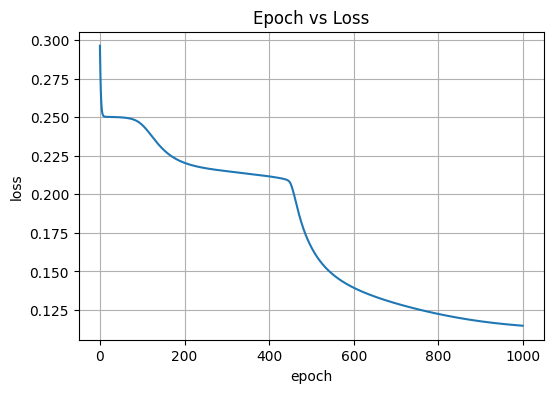

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Epoch vs Loss")
plt.grid(True)
plt.show()

### 3.2.真の境界線との比較

今回のデータはXOR構造（x1=5.5、 x2=5.5 を境界とした4象限分類）なので、真の境界は縦線と横線の2本になる。  
ニューラルネットは直線的な変換の組み合わせで境界を表現するため、XORのような非線形の境界を隠れ層2ニューロンで完全に再現するのは難しかった。

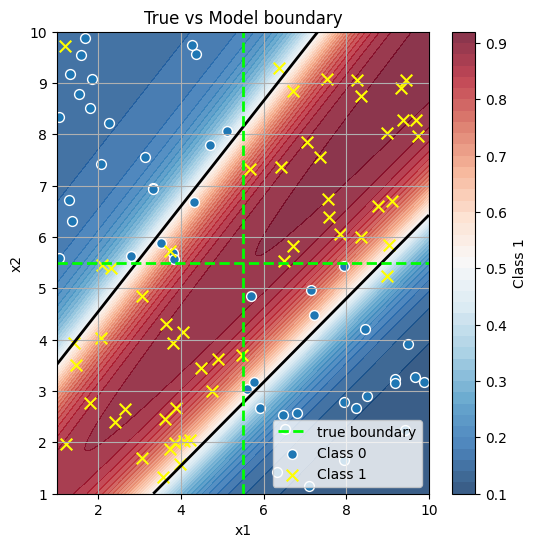

In [32]:
plt.figure(figsize=(6, 6))

cp = plt.contourf(X1, X2, O21_grid, levels=50, cmap="RdBu_r", alpha=0.8)
plt.colorbar(cp, label="Class 1")
plt.contour(X1, X2, O21_grid, levels=[0.5], colors="black", linewidths=2)

plt.axvline(x=5.5, color="lime", linewidth=2, linestyle="--", label="true boundary")
plt.axhline(y=5.5, color="lime", linewidth=2, linestyle="--")
plt.scatter(input_data[labels==0, 0], input_data[labels==0, 1], marker="o", edgecolors="white", s=50, label="Class 0")
plt.scatter(input_data[labels==1, 0], input_data[labels==1, 1], marker="x", color="yellow", s=70, label="Class 1")

plt.title("True vs Model boundary")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend(); plt.grid(True)
plt.xlim(1, 10); plt.ylim(1, 10)
plt.show()